**VERSION vPaper**: Shows the plots of the alphas obtained in the paper (I think).

### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [29]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_cons as sim
import satellite_RFI.src.plots as plots
import natsort
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [31]:
## ----- FITTING PARAMETERS ----- ##
# folder and name of final results file
folder = "/idia/projects/hi_im/satellite_rfi/Testing/{}/test_results_sat_12/".format(pm.block)


In [32]:
pm.show_parameters(plotting=True)
print("")
print(f"Showing results from folder: {folder}")


Block: 1551055211
Frequency range: 1100 - 1350 MHz

Showing results from folder: /idia/projects/hi_im/satellite_rfi/Testing/1551055211/test_results_sat_12/


### 2. Figures from the article

#### 2.0 Setting up

We start by defining some global variables (like the simulation and some functions) which will be the same for all of the masks.

In [33]:
# we can use the same object throughout everything, only the mask changes
print("Simulating...")
sat = sim.SatelliteSimulation(
        block=str(pm.block),
        use_data=True,
        path_data=pm.path_data,
        path_beam=pm.path_data,
        survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
        path_catalog="Satellite_Catalogue/satellite_constellation_catalog.csv",
        beam_model=pm.beam_model,
        freq_range=[pm.fs, pm.fe],
        freq_slice=[pm.fs_slice, pm.fe_slice],
        time_slice=[None,None],
        include_cons=pm.include_cons,
        verbose=True,
    )
print("Done")

# these values are the same always
fs = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
ts = sat.nd_s0[sat.itime[0]:sat.itime[1]]
N = len(sat.catalog["Alpha"])


Simulating...
Getting catalog...
Number of signals in satellite catalog:  21
Getting beam response (2GB) ...
Number of constellations present:  6
Getting temperature factors for each signal...
Starting index of constellations:  [ 0  4  9 13 18 20]
Getting observational data...
Done


In [34]:
## ----- RETRIEVING ALPHA VALUES FROM PAPER ----- ##

def get_alphas_paper(folder):
    ''' Retrieves results from initial calculation (from the paper). '''
    
    # getting the folder with values
    loc = '/idia/projects/hi_im/satellite_rfi/Testing/{}/test_results_sat_12{}'.format(pm.block,folder)
    file_list = os.listdir(loc)
    file_list = natsort.natsorted(file_list, key=lambda y: y.lower())

    # selecting the C1 and C2 files
    idx = np.arange(len(file_list))
    results_C1 = [pickle.load(open(loc+file_list[di],'rb')) for di in idx[::2]]
    results_C2 = [pickle.load(open(loc+file_list[di],'rb')) for di in idx[1::2]]
    
    return results_C1, results_C2


In [40]:
## ----- PLOTTING FUNCTIONS ----- ##

def plot_alphas(alphas, pars_mask, title):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,p in enumerate(pars_mask):
        axs[0].plot(xs, alphas[p][0], points[i], label="{}: {}".format(title,p))
        axs[1].plot(xs, alphas[p][1], points[i], label="{}: {}".format(title,p))

    # showing figure
    fig.suptitle(r'Block: {} {} Mask'.format(pm.block,title))
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, N + 1))
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_errors(alphas, pars_mask, title, folderT):
    ''' Creates the plot of absolute errors for alphas in C1 and C2. '''

    # retrieving values from paper
    # for this to work, labels must be alfabetically ordered
    results_C1,results_C2 = get_alphas_paper(folderT)
    alphasT = {lab: [results_C1[i]["best-fit"],results_C2[i]["best-fit"]] for i,lab in enumerate(pars_mask)}
    errors = {p: [np.abs(alphasT[p][0]-alphas[p][0]), np.abs(alphasT[p][1]-alphas[p][1])] for p in pars_mask}

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,p in enumerate(pars_mask):
        axs[0].plot(xs, errors[p][0], points[i], label="{}: {}".format(title,p))
        axs[1].plot(xs, errors[p][1], points[i], label="{}: {}".format(title,p))

    # showing figure
    fig.suptitle(r'{} Mask - Error in alphas'.format(title))
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, N + 1))
        ax.set_ylabel('Absolute error')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    fig.tight_layout()
    fig.show()

    # printing useful values
    print("Maximum absolute errors:")
    for p in pars_mask:
        print(" - With {} = {}:".format(title,p))
        for i in range(2):  
            arg = np.argmax(errors[p][i])
            print("    - C{}: {:.3e}, for a{} = {:.3e}".format(
                i,np.max(errors[p][i]),arg,alphasT[p][i][arg]))
    print("Maximum relative errors:")
    for p in pars_mask:
        print(" - With {} = {}:".format(title,p))
        for i in range(2): 
            arg = np.argmax(errors[p][i]/alphasT[p][i])
            print("    - C{}: {:.3e}%, for a{} = {:.3e}".format(
                i,100*np.max(errors[p][i]/alphasT[p][i]),arg,alphasT[p][i][arg]))

# ----------------------------------------------- #

def plot_1d(observations, simulations, CFs, pars_mask, title):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(pars_mask)), nrows=len(pars_mask), ncols=2, sharey=True)
    fig.suptitle(r'Block {}, {} Mask'.format(pm.block, title))

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(pars_mask):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(fs, np.ma.mean(observations[label]+sat.observations_BG.T, axis=0), label='Observation')
            ax.plot(fs, np.ma.mean(simulations[label][iCF]+sat.observations_BG.T, axis=0), '--', label='Simulation')

            # defining figure
            textstr = "$\\sigma_D={}$\n{}={}\nFoM$={:.3f}$".format(CF,title,label,CFs[label][iCF])
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d(observations, simulations, pars_mask, title):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(pars_mask)), nrows=len(pars_mask), ncols=3,
                           sharey=True, sharex=True)
    fig.suptitle("Block {}, {} Mask".format(pm.block, title))

    for ilabel,label in enumerate(pars_mask):
        for idata,data in enumerate([observations[label], simulations[label][0], simulations[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            default = observations[label] + sat.observations_BG.T
            cax = ax.imshow(data + sat.observations_BG.T, aspect='auto', extent=[fs[0],fs[-1],ts[-1],ts[0]], 
                            vmax=np.max(default), vmin=np.ma.min(default))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()

# ------------ PLOTTING FUNCTIONS (only for no mask) --------------- #

def plot_alphas_nomask(alphas):
    ''' Creates the plot of alpha values for C1 and C2. '''
    
    # plotting values
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    xs = np.arange(1, N + 1)
    ax.plot(xs, alphas[0], 'o', label=r'$\sigma_D=C_1$')
    ax.plot(xs, alphas[1], '*', label=r'$\sigma_D=C_2$')
    ax.axhline(0, color='black', linestyle='--')

    # creating figure
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, N + 1))
    ax.set_title(r'Block: {} No-Mask'.format(pm.block))
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')
    ax.legend()
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_errors_nomask(alphas):
    ''' Creates the plot of absolute errors for alphas, for C1 and C2. '''

    # retrieving values from paper
    frac,resi = get_alphas_paper("/no_mask/")
    alphasT = [frac[0]["best-fit"],resi[0]["best-fit"]]
    errors = [np.abs(alphasT[i]-alphas[i]) for i in range(len(alphas))]
    
    # plotting values
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    xs = np.arange(1, N + 1)
    ax.plot(xs, errors[0], 'o', label=r'$\sigma_D=C_1$')
    ax.plot(xs, errors[1], '*', label=r'$\sigma_D=C_2$')
    ax.axhline(0, color='black', linestyle='--')

    # creating figure
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, N + 1))
    ax.set_title(r'No-Mask Differences')
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Absolute error')
    ax.legend()
    fig.tight_layout()
    fig.show()

    # printing useful values
    print("Maximum absolute errors:")
    for i in range(2):  
        arg = np.argmax(errors[i])
        print(" - C{}: {:.3e}, for a{} = {:.3e}".format(
            i,np.max(errors[i]),arg,alphasT[i][arg]))
    print("Maximum relative errors:")
    for i in range(2): 
        arg = np.argmax(errors[i]/alphasT[i])
        print(" - C{}: {:.3e}%, for a{} = {:.3e}".format(
            i,100*np.max(errors[i]/alphasT[i]),arg,alphasT[i][arg]))

# ----------------------------------------------- #

def plot_1d_nomask(simulations, CFs):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))

    for i,CF in enumerate(["C_1","C_2"]):
        # plotting values
        ax = axs[i]
        ax.plot(fs, np.ma.mean(sat.observations_sat.T + sat.observations_BG.T, axis=0), label='Observation')
        ax.plot(fs, np.ma.mean(simulations[i] + sat.observations_BG.T, axis=0), '--', label='Simulation')
        
        # defining figure
        ax.set_ylabel('Temperature [K]')
        ax.set_xlabel('Frequency [MHz]')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        textstr = "$\\sigma_{{D}}={}$\nFoM={:.2f}".format(CF,CFs[i])
        ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.legend(loc="upper left")

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_2d_nomask(simulations):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))  
    titles = ['Observation', r'$C_1$', r'$C_2$']
    
    for i,data in enumerate([sat.observations_sat.T, simulations[0], simulations[1]]):
        # plotting values
        ax = axs[i]
        default = sat.observations_sat.T + sat.observations_BG.T
        cax = ax.imshow(data + sat.observations_BG.T, aspect='auto', extent=[fs[0], fs[-1], ts[-1], ts[0]], 
                        vmax=np.max(default), vmin=np.min(default))

        # defining figure
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_title(titles[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

#### 2.1 No Masking

We start by retrieving the values, and then plot using the same plots as the paper. Finally, we compare them to the original alphas.

In [37]:
# storing values
simulations = []
CFs = []

# getting values from paper
results_C1, results_C2 = get_alphas_paper("/no_mask/")
alphas = [results_C1[0]["best-fit"],results_C2[0]["best-fit"]]

for i,CF in enumerate(["C1","C2"]):
    # getting values
    print("Getting values for no mask and CF = {}.".format(CF))
    alphasi = alphas[i]
    sat.execute(alphasi)

    # saving values
    simulations.append(np.ma.masked_equal(sat.simulation.T,0))
    if CF=="C1":  
        CFs.append(np.sum(((sat.observations_sat-sat.simulation)/sat.observations)**2) / simulations[-1].size)
    elif CF=="C2":  
        CFs.append(np.sum((sat.observations_sat-sat.simulation)**2) / simulations[-1].size)
    

Getting values for no mask and CF = C1.
Getting values for no mask and CF = C2.


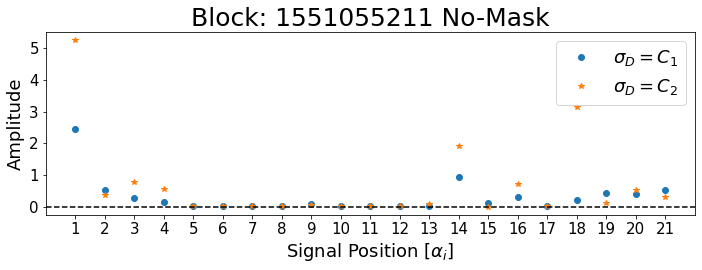

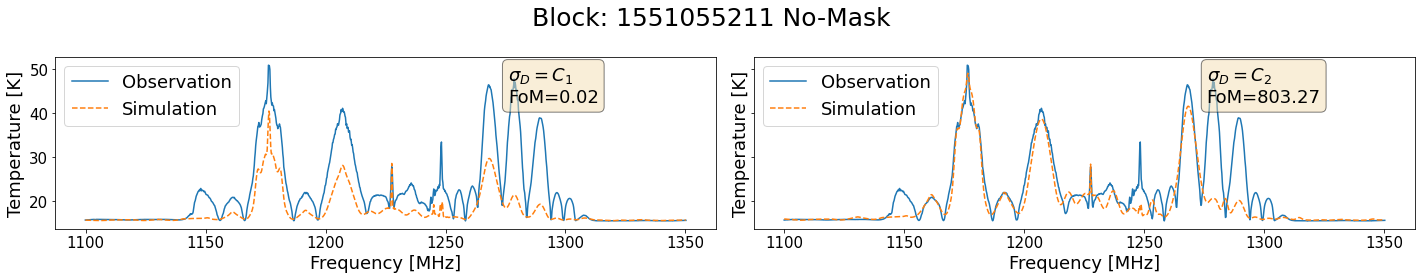

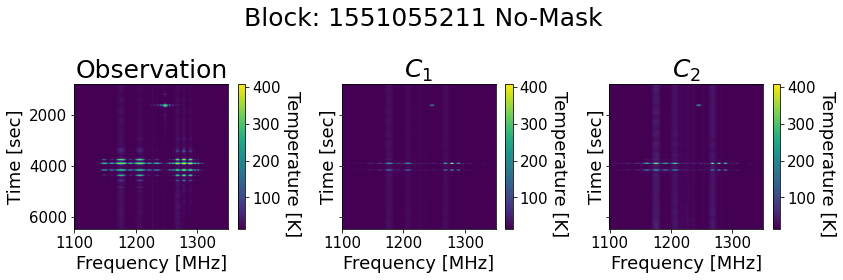

In [38]:
# plotting all things
plot_alphas_nomask(alphas)
plot_1d_nomask(simulations, CFs)
plot_2d_nomask(simulations)

#### 2.2 Angular masking

Now we create functions to display the plots, we use these ones for the rest of the masks.

In [42]:
# storing values
pars = ["1F","5F"]
simulations = {p: [] for p in pars}
CFs = {p: [] for p in pars}
observations = {}

# getting results from paper
results_C1,results_C2 = get_alphas_paper("/degree_mask/")
alphas = {p: [results_C1[i]["best-fit"],results_C2[i]["best-fit"]] for i,p in enumerate(pars)}

for p in pars:
    # creating mask
    path_nearby = pm.path_data + "nearby_satellites/nearby_satellite_close_angle_" + p + ".p"
    sat.create_mask(path_nearby=path_nearby, apply=False)
    observations[p] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for i,CF in enumerate(["C1","C2"]):
        # getting values
        print("Getting values for degree = {} and CF = {}.".format(p,CF))
        alphasi = alphas[p][i]
        sat.execute_withmask(alphasi)
        simulations[p].append(np.ma.masked_equal(sat.simulation.T,0))
        
        # calculating CF
        matrix = sat.observations_sat*sat.mask-sat.simulation
        if CF=="C1":  CFs[p].append(np.sum(matrix/sat.observations)**2 / Npoints)
        else:  CFs[p].append(np.sum(matrix**2 ) / Npoints)


Getting values for degree = 1F and CF = C1.
Getting values for degree = 1F and CF = C2.
Getting values for degree = 5F and CF = C1.
Getting values for degree = 5F and CF = C2.


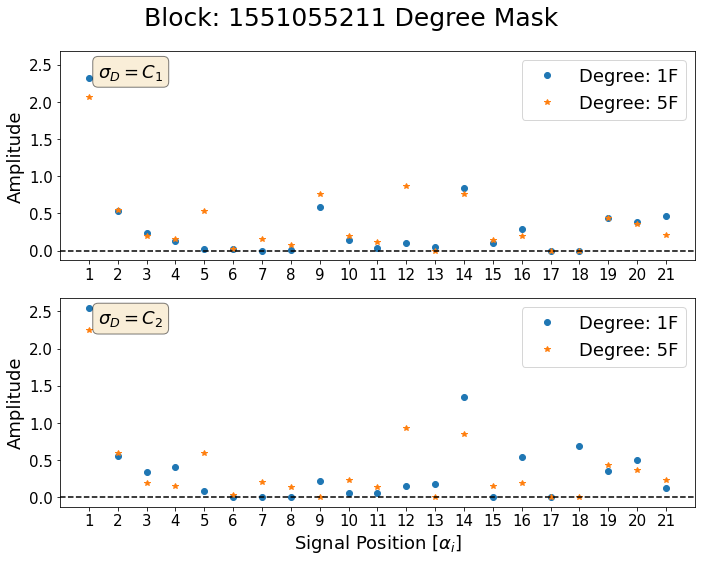

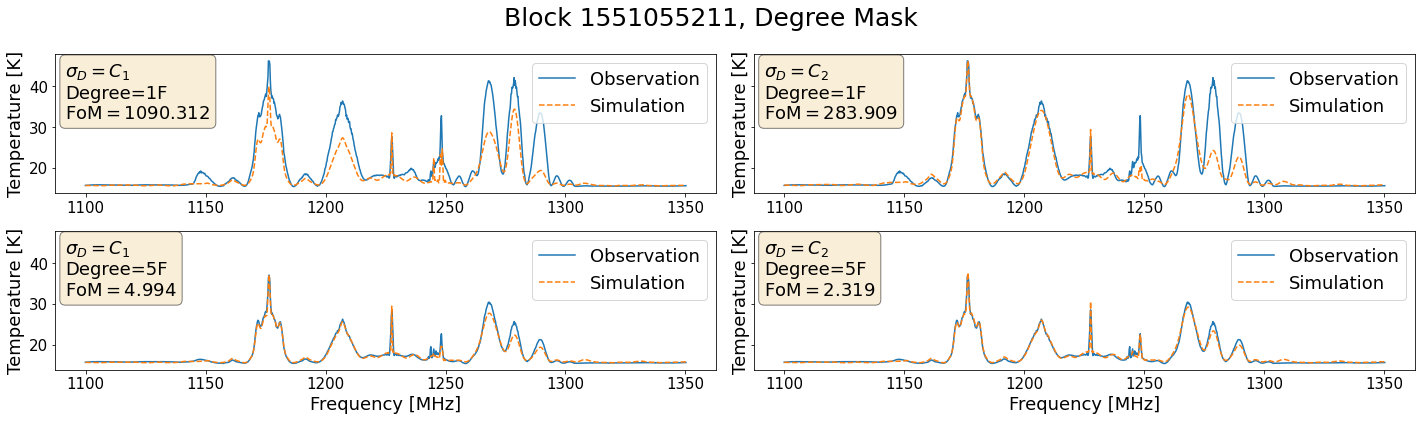

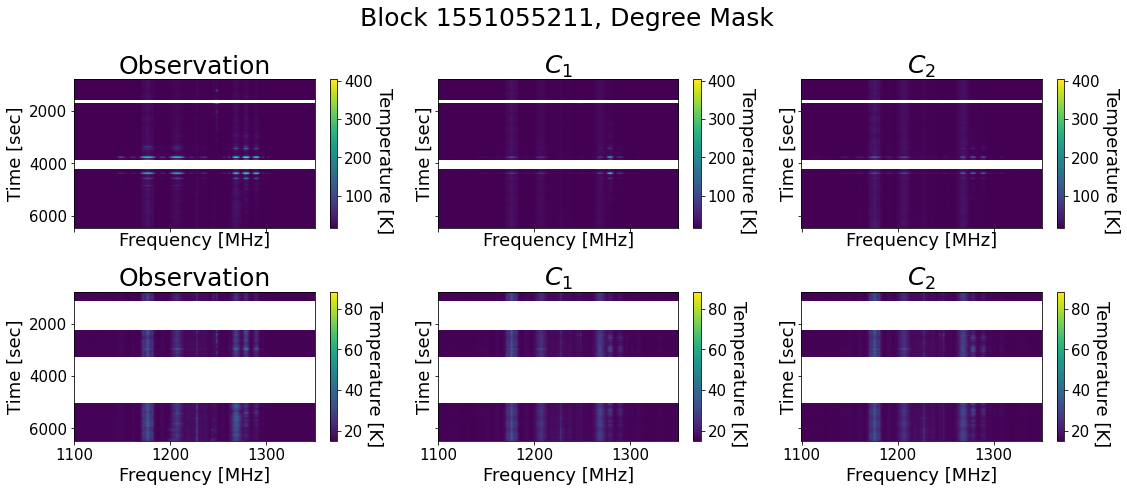

In [43]:
# showing plots
pars_mask = ["1F","5F"]
title = "Degree"
plot_alphas(alphas, pars_mask, title)
plot_1d(observations, simulations, CFs, pars_mask, title)
plot_2d(observations, simulations, pars_mask, title)

#### 2.3 Thermal masking

In [44]:
# storing values
pars = [25,50,100]
simulations = {p: [] for p in pars}
CFs = {p: [] for p in pars}
observations = {}

# getting results from paper
results_C1,results_C2 = get_alphas_paper("/thermal_mask/")
alphas = {p: [results_C1[i]["best-fit"],results_C2[i]["best-fit"]] for i,p in enumerate(pars)}

for p in pars:
    # creating mask
    sat.create_mask(temperature=p, apply=False)
    observations[p] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for CF in ["C1","C2"]:
        # getting values
        print("Getting values for temperature = {} and CF = {}.".format(p,CF))
        alphasi = alphas[p][i]
        sat.execute_withmask(alphasi)
        simulations[p].append(np.ma.masked_equal(sat.simulation.T,0))
        
        # calculating CF
        matrix = sat.observations_sat*sat.mask-sat.simulation
        if CF=="C1":  CFs[p].append(np.sum(matrix/sat.observations)**2 / Npoints)
        else:  CFs[p].append(np.sum(matrix**2 ) / Npoints)


Getting values for temperature = 25 and CF = C1.
Getting values for temperature = 25 and CF = C2.
Getting values for temperature = 50 and CF = C1.
Getting values for temperature = 50 and CF = C2.
Getting values for temperature = 100 and CF = C1.
Getting values for temperature = 100 and CF = C2.


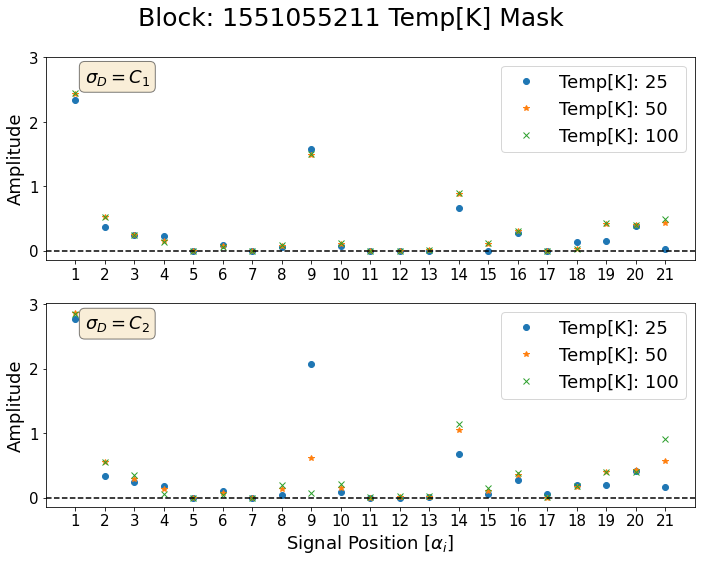

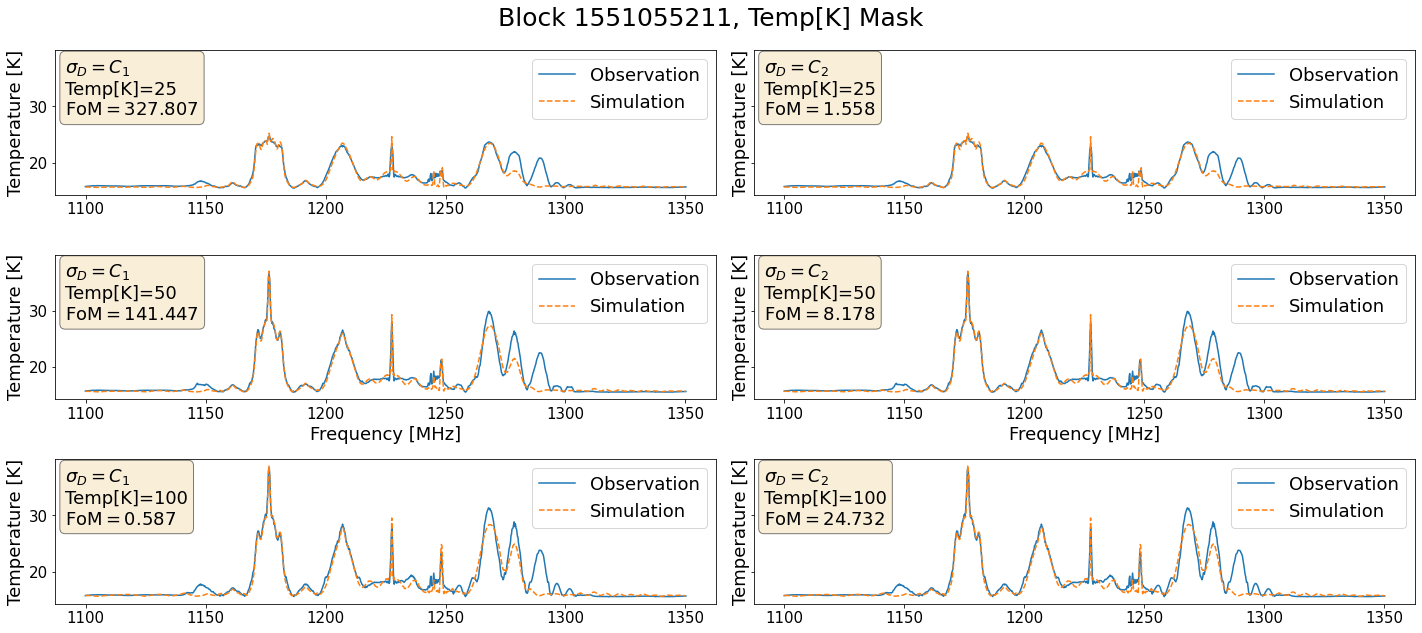

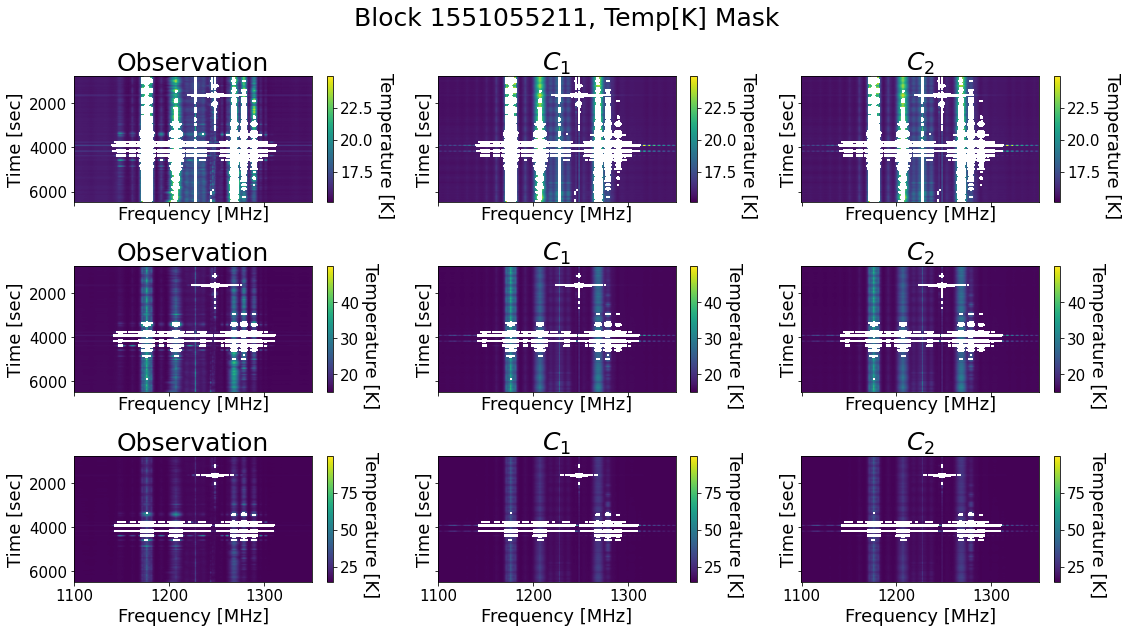

In [45]:
# showing plots
pars_mask = [25,50,100]
title = "Temp[K]"
plot_alphas(alphas, pars_mask, title)
plot_1d(observations, simulations, CFs, pars_mask, title)
plot_2d(observations, simulations, pars_mask, title)

#### 2.4 Pixel-timeline Masking

NOTA: Não tenho a certeza como os ficheiros estão guardados (o nome) e portanto não sei se a ordem correta é 2->5->7 ou 7->5->2. Não tenho sequer a certeza se definiram desta maneira, no paper está assim definido mas se calhar as contas na verdade usaram uma temperature T=const e calcularam previamente o T=Tmax/(X) para terem valores redondos da temperatura.

In [35]:
# storing values
pars = [2,5,7]
alphas = {p: [] for p in pars}
simulations = {p: [] for p in pars}
CFs = {p: [] for p in pars}
observations = {}

for p in pars:
    # creating mask
    sat.create_mask(pix=p, apply=False)
    observations[p] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for CF in ["C1","C2"]:
        # getting values
        print("Getting values for timeline temperature = {} and CF = {}.".format(p,CF))
        alphasi = pickle.load( open(pm.my_name(folder,CF,pix=p),'rb') )["best-fit"]
        sat.execute_withmask(alphasi)
        alphas[p].append(alphasi)
        simulations[p].append(np.ma.masked_equal(sat.simulation.T,0))
        
        # calculating CF
        matrix = sat.observations_sat*sat.mask-sat.simulation
        if CF=="C1":  CFs[p].append(np.sum(matrix/sat.observations)**2 / Npoints)
        else:  CFs[p].append(np.sum(matrix**2 ) / Npoints)


Getting values for timeline temperature = 2 and CF = C1.
Getting values for timeline temperature = 2 and CF = C2.
Getting values for timeline temperature = 5 and CF = C1.
Getting values for timeline temperature = 5 and CF = C2.
Getting values for timeline temperature = 7 and CF = C1.
Getting values for timeline temperature = 7 and CF = C2.


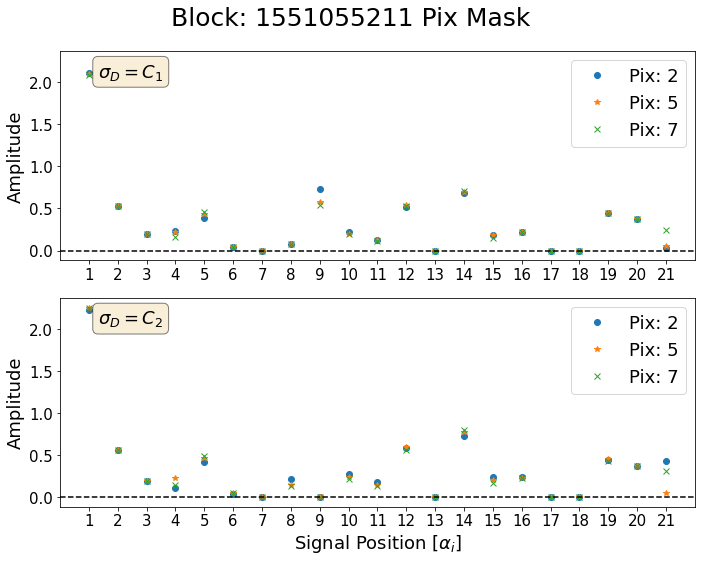

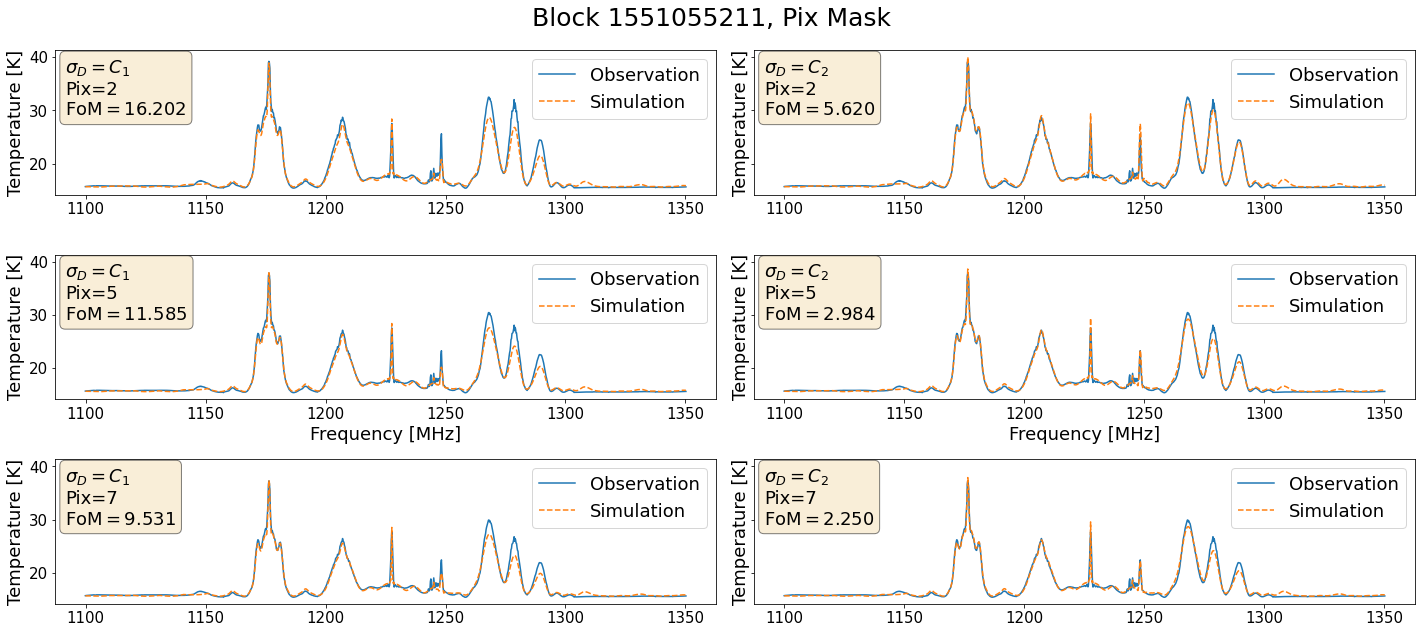

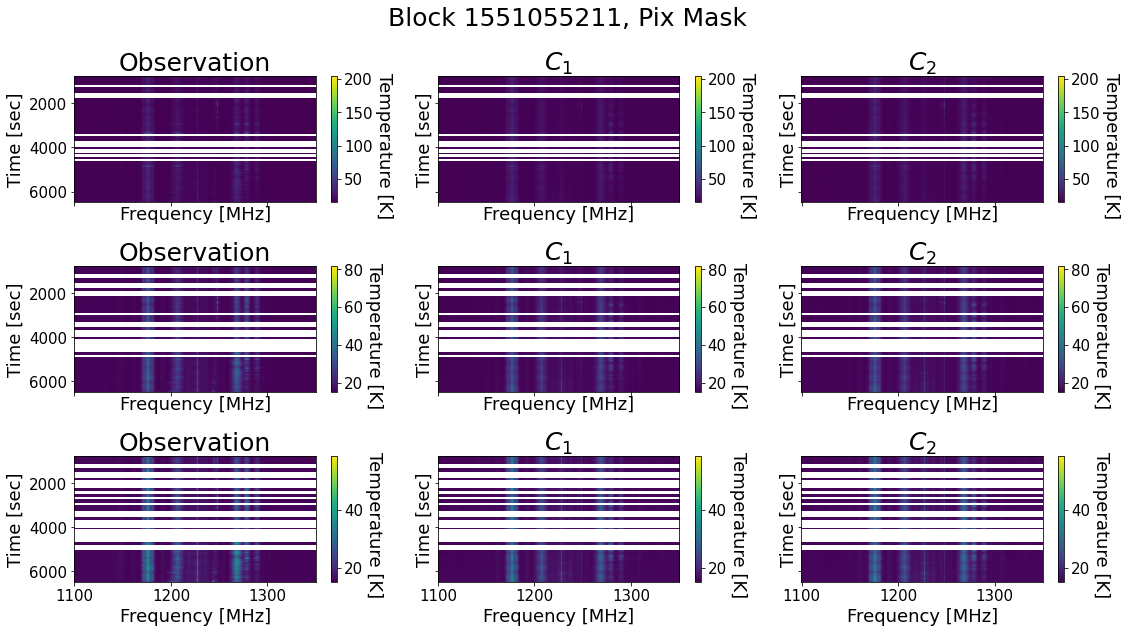

In [36]:
# showing plots
pars_mask = [2,5,7]
title = "Pix"
plot_alphas(alphas, pars_mask, title)
plot_1d(observations, simulations, CFs, pars_mask, title)
plot_2d(observations, simulations, pars_mask, title)

In [29]:
plot_errors(alphas, pars_mask, title, "/")  # <-- os resultados para esta secção em específico 
# não foram guardados numa pasta própria mas apenas na pasta geral de resultados, não sei porquê.

IsADirectoryError: [Errno 21] Is a directory: '/idia/projects/hi_im/satellite_rfi/Testing/1551055211/test_results_sat_12/1.'

#### 3.5 Time slicing

NOTA: Por fazer, será necessário rescrever as funções para as plots. Não demora muito tempo mas devem ser os resultados iguais a antes e corretos portanto não é urgente.